# Penentuan Lokasi SPKLU dengan P-Median — Paket Lengkap Usia 25–60

Notebook ini menjalankan seluruh alur dalam satu paket:

1. Membaca jumlah kendaraan listrik roda empat per wilayah SAMSAT.
2. Membaca penduduk usia 25–60 tahun per kecamatan.
3. Mengestimasi penduduk usia sasaran pada setiap kelurahan.
4. Membentuk Himpunan $I$ berupa satu titik permintaan per kelurahan.
5. Membaca dan membersihkan Himpunan $J$ berupa kandidat lokasi SPKLU.
6. Menghitung matriks jarak menggunakan jaringan jalan.
7. Menjalankan model p-median untuk beberapa nilai $p$.
8. Menyimpan lokasi terpilih, assignment, ringkasan, dan peta.

Model objektif:

$$\min \sum_i\sum_j w_i d_{ij}x_{ij}$$

dengan $w_i$ sebagai estimasi EV berbobot demografi usia 25–60 pada kelurahan $i$ dan $d_{ij}$ sebagai jarak jaringan jalan.

> **Asumsi umur 60:** sumber hanya menyediakan interval 60–64. Jumlah penduduk usia tepat 60 tahun diestimasi sebesar $1/5$ dari kelompok 60–64 dengan asumsi distribusi usia seragam. Ubah `ESTIMASI_UMUR_60 = False` jika penelitian akan menggunakan rentang 25–59 tanpa asumsi.


## 0. Persiapan file

Letakkan notebook ini di folder `notebooks/` dengan struktur:

```text
spklu_bandung/
├── data/
│   ├── raw/
│   │   ├── Kendaraan Listrik Bdg Raya.xlsx
│   │   ├── jumlah_penduduk_kota_bandung_berdasarkan_kelompok_u_1.xlsx
│   │   ├── penduduk_kelurahan_bandung.csv
│   │   └── kelurahan_bandung.json
│   └── processed/
│       ├── kandidat_J_gabungan_final.csv
│       └── bandung_drive_utm48s.graphml
└── notebooks/
    └── 04_pmedian_spklu_lengkap_usia_25_60.ipynb
```

Jika `pulp` belum tersedia, jalankan sekali `%pip install pulp` lalu restart kernel.


In [43]:
# Jika diperlukan, buka komentar pada baris berikut lalu jalankan sekali
# %pip install pulp

from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import folium
from pulp import (
    LpProblem, LpMinimize, LpVariable, lpSum,
    LpBinary, PULP_CBC_CMD, LpStatus, value
)

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pmedian_usia_25_60_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EV_XLSX = RAW_DIR / "Kendaraan Listrik Bdg Raya.xlsx"
AGE_XLSX = RAW_DIR / "jumlah_penduduk_kota_bandung_berdasarkan_kelompok_u_1.xlsx"
POP_CSV = RAW_DIR / "penduduk_kelurahan_bandung.csv"
KELURAHAN_FILE = RAW_DIR / "kelurahan_bandung.json"
CANDIDATE_CSV = PROCESSED_DIR / "kandidat_J_gabungan_final.csv"
GRAPH_FILE = PROCESSED_DIR / "bandung_drive_utm48s.graphml"

UTM_EPSG = 32748
P_SCENARIOS = [5, 10, 15, 20, 25]
ESTIMASI_UMUR_60 = True

for path in [EV_XLSX, AGE_XLSX, POP_CSV, KELURAHAN_FILE, CANDIDATE_CSV, GRAPH_FILE]:
    assert path.exists(), f"File tidak ditemukan: {path}"

print("Semua file input ditemukan.")
print("Metode umur:", "25–60 (umur 60 diestimasi)" if ESTIMASI_UMUR_60 else "25–59")


Semua file input ditemukan.
Metode umur: 25–60 (umur 60 diestimasi)


## 1. Baca data EV roda empat

SPKLU dalam analisis ini diasumsikan melayani mobil listrik, sehingga kolom yang digunakan adalah `jumlah_roda_4`, bukan total roda dua dan roda empat.


In [44]:
ev_raw = pd.read_excel(EV_XLSX, sheet_name="CustomQuery")

def nama_samsat(teks):
    teks = str(teks).lower()
    if "pajajaran" in teks:
        return "Pajajaran"
    if "kawaluyaan" in teks:
        return "Kawaluyaan"
    if "soekarno hatta" in teks:
        return "Soekarno Hatta"
    return None

ev_raw["wilayah_samsat"] = ev_raw["nama_wilayah"].apply(nama_samsat)
ev_bandung = ev_raw.dropna(subset=["wilayah_samsat"]).copy()
EV_PER_WILAYAH = dict(zip(ev_bandung["wilayah_samsat"], ev_bandung["jumlah_roda_4"]))

assert set(EV_PER_WILAYAH) == {"Pajajaran", "Kawaluyaan", "Soekarno Hatta"}
TOTAL_EV = int(sum(EV_PER_WILAYAH.values()))

print(EV_PER_WILAYAH)
print(f"Total EV roda empat Kota Bandung: {TOTAL_EV:,}")
assert TOTAL_EV == 7136, "Total EV berbeda dari Excel yang diperiksa; cek data sumber."


{'Pajajaran': 2667, 'Kawaluyaan': 2420, 'Soekarno Hatta': 2049}
Total EV roda empat Kota Bandung: 7,136


d:\Magang\Week 1\spklu_bandung\venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 2. Bentuk bobot demografi usia 25–60 per kecamatan

Data umur tersedia pada tingkat kecamatan. Notebook mengambil periode terbaru yang lengkap, menjumlahkan kelompok 25–59, kemudian—jika `ESTIMASI_UMUR_60=True`—menambahkan seperlima kelompok 60–64 sebagai estimasi usia tepat 60 tahun.

Data penduduk total kelurahan kemudian digunakan untuk mendistribusikan penduduk usia sasaran dari kecamatan ke kelurahan secara proporsional.


In [45]:
KECAMATAN_KE_SAMSAT = {
    "ANDIR": "Pajajaran", "ASTANA ANYAR": "Pajajaran",
    "BABAKAN CIPARAY": "Pajajaran", "BANDUNG KULON": "Pajajaran",
    "BOJONGLOA KALER": "Pajajaran", "BOJONGLOA KIDUL": "Pajajaran",
    "CICENDO": "Pajajaran", "SUKAJADI": "Pajajaran", "SUKASARI": "Pajajaran",

    "BANDUNG WETAN": "Kawaluyaan", "BATUNUNGGAL": "Kawaluyaan",
    "CIBEUNYING KALER": "Kawaluyaan", "CIBEUNYING KIDUL": "Kawaluyaan",
    "CIDADAP": "Kawaluyaan", "COBLONG": "Kawaluyaan",
    "KIARACONDONG": "Kawaluyaan", "LENGKONG": "Kawaluyaan",
    "REGOL": "Kawaluyaan", "SUMUR BANDUNG": "Kawaluyaan",

    "ANTAPANI": "Soekarno Hatta", "ARCAMANIK": "Soekarno Hatta",
    "BANDUNG KIDUL": "Soekarno Hatta", "BUAH BATU": "Soekarno Hatta",
    "CIBIRU": "Soekarno Hatta", "CINAMBO": "Soekarno Hatta",
    "GEDE BAGE": "Soekarno Hatta", "MANDALAJATI": "Soekarno Hatta",
    "PANYILEUKAN": "Soekarno Hatta", "RANCASARI": "Soekarno Hatta",
    "UJUNGBERUNG": "Soekarno Hatta",
}

def normalisasi(teks):
    return re.sub(r"[^A-Z0-9]", "", str(teks).upper())

MAP_SAMSAT_NORM = {normalisasi(k): v for k, v in KECAMATAN_KE_SAMSAT.items()}

# --- Data umur terbaru ---
umur = pd.read_excel(AGE_XLSX, sheet_name="data")
periode = umur[["tahun", "semester"]].drop_duplicates().sort_values(["tahun", "semester"])
tahun_terbaru, semester_terbaru = periode.iloc[-1].tolist()
umur_latest = umur[(umur["tahun"] == tahun_terbaru) &
                   (umur["semester"] == semester_terbaru)].copy()

assert umur_latest["bps_kode_kecamatan"].nunique() == 30, (
    "Periode terbaru tidak mencakup 30 kecamatan. Pilih periode lengkap secara manual."
)

kelompok_25_59 = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59"]
usia_25_59 = (
    umur_latest[umur_latest["kelompok_umur"].isin(kelompok_25_59)]
    .groupby(["bps_kode_kecamatan", "bps_nama_kecamatan"], as_index=False)["jumlah_penduduk"]
    .sum()
    .rename(columns={"jumlah_penduduk": "penduduk_usia_25_59"})
)

usia_60 = (
    umur_latest[umur_latest["kelompok_umur"] == "60-64"]
    [["bps_kode_kecamatan", "jumlah_penduduk"]]
    .rename(columns={"jumlah_penduduk": "penduduk_usia_60_64"})
)

usia_kecamatan = usia_25_59.merge(usia_60, on="bps_kode_kecamatan", how="left")
usia_kecamatan["estimasi_usia_60"] = usia_kecamatan["penduduk_usia_60_64"] / 5
usia_kecamatan["penduduk_usia_target"] = usia_kecamatan["penduduk_usia_25_59"]
if ESTIMASI_UMUR_60:
    usia_kecamatan["penduduk_usia_target"] += usia_kecamatan["estimasi_usia_60"]

usia_kecamatan["kecamatan_key"] = usia_kecamatan["bps_nama_kecamatan"].apply(normalisasi)
usia_kecamatan["wilayah_samsat"] = usia_kecamatan["kecamatan_key"].map(MAP_SAMSAT_NORM)
assert usia_kecamatan["wilayah_samsat"].notna().all(), "Ada kecamatan umur yang belum masuk peta SAMSAT."

# --- Penduduk total terbaru per kelurahan ---
pop = pd.read_csv(POP_CSV)
sort_cols = [c for c in ["tahun", "semester"] if c in pop.columns]
if sort_cols:
    pop = pop.sort_values(sort_cols)

pop_latest = (
    pop.groupby("bps_desa_kelurahan", as_index=False)
       .last()[["bps_nama_kecamatan", "bps_desa_kelurahan", "jumlah_penduduk"]]
       .rename(columns={
           "bps_nama_kecamatan": "nama_kecamatan",
           "bps_desa_kelurahan": "nama_kelurahan"
       })
)
pop_latest["kecamatan_key"] = pop_latest["nama_kecamatan"].apply(normalisasi)

print(f"Periode data umur: semester {semester_terbaru} tahun {tahun_terbaru}")
print(f"Jumlah kecamatan umur: {len(usia_kecamatan)}")
print(f"Jumlah kelurahan penduduk: {len(pop_latest)}")
print(f"Total penduduk usia target tingkat kecamatan: {usia_kecamatan['penduduk_usia_target'].sum():,.1f}")
display(usia_kecamatan.head())


Periode data umur: semester 2 tahun 2025
Jumlah kecamatan umur: 30
Jumlah kelurahan penduduk: 151
Total penduduk usia target tingkat kecamatan: 1,316,144.2


,bps_kode_kecamatan,bps_nama_kecamatan,penduduk_usia_25_59,penduduk_usia_60_64,estimasi_usia_60,penduduk_usia_target,kecamatan_key,wilayah_samsat
0,3273010,BANDUNG KULON,69830,5437,1087.4,70917.4,BANDUNGKULON,Pajajaran
1,3273020,BABAKAN CIPARAY,73548,5459,1091.8,74639.8,BABAKANCIPARAY,Pajajaran
2,3273030,BOJONGLOA KALER,62419,5330,1066.0,63485.0,BOJONGLOAKALER,Pajajaran
3,3273040,BOJONGLOA KIDUL,44877,3625,725.0,45602.0,BOJONGLOAKIDUL,Pajajaran
4,3273050,ASTANAANYAR,35952,3599,719.8,36671.8,ASTANAANYAR,Pajajaran


## 3. Distribusikan penduduk usia target ke kelurahan dan gabungkan poligon

Karena data umur hanya tersedia per kecamatan, jumlah usia target kecamatan dibagi ke kelurahan berdasarkan proporsi penduduk total kelurahan terhadap total penduduk kecamatan. Total hasil distribusi wajib sama dengan total sumber pada tingkat kecamatan.


In [46]:
from difflib import SequenceMatcher

# Gabungkan umur kecamatan ke tabel kelurahan
kel_age = pop_latest.merge(
    usia_kecamatan[["kecamatan_key", "penduduk_usia_target", "wilayah_samsat"]],
    on="kecamatan_key",
    how="left"
)
assert kel_age["penduduk_usia_target"].notna().all(), "Ada kelurahan yang gagal memperoleh data umur."

kel_age["total_penduduk_kecamatan"] = (
    kel_age.groupby("kecamatan_key")["jumlah_penduduk"].transform("sum")
)
kel_age["proporsi_penduduk_kelurahan"] = (
    kel_age["jumlah_penduduk"] / kel_age["total_penduduk_kecamatan"]
)
kel_age["estimasi_usia_25_60"] = (
    kel_age["penduduk_usia_target"] * kel_age["proporsi_penduduk_kelurahan"]
)

assert np.isclose(
    kel_age["estimasi_usia_25_60"].sum(),
    usia_kecamatan["penduduk_usia_target"].sum(),
    atol=1e-6
), "Total umur berubah saat didistribusikan ke kelurahan."

# Baca poligon dan deteksi kolom nama kelurahan berdasarkan kecocokan terbesar
kel = gpd.read_file(KELURAHAN_FILE)
if kel.crs is None:
    kel = kel.set_crs("EPSG:4326")

pop_keys = set(kel_age["nama_kelurahan"].apply(normalisasi))
candidate_cols = [c for c in kel.columns if c != kel.geometry.name]
scores = {}
for col in candidate_cols:
    keys = set(kel[col].dropna().astype(str).apply(normalisasi))
    scores[col] = len(keys & pop_keys)

KEL_NAME_COL = max(scores, key=scores.get)
kel["kelurahan_key"] = kel[KEL_NAME_COL].apply(normalisasi)
kel_age["kelurahan_key"] = kel_age["nama_kelurahan"].apply(normalisasi)

# Alias yang telah diverifikasi dapat ditulis manual di sini jika diperlukan.
# Format: {"NAMA_DARI_DATA_PENDUDUK": "NAMA_DARI_GEOJSON"}
ALIAS_KELURAHAN_MANUAL = {}
kel_age["kelurahan_key"] = kel_age["kelurahan_key"].replace(ALIAS_KELURAHAN_MANUAL)

# Cari nama yang belum cocok dan pasangkan secara otomatis hanya jika
# skor kemiripannya tinggi. Setiap nama GeoJSON hanya boleh dipakai sekali.
geo_keys = set(kel["kelurahan_key"])
penduduk_keys = set(kel_age["kelurahan_key"])
missing_penduduk = sorted(penduduk_keys - geo_keys)
missing_geojson = sorted(geo_keys - penduduk_keys)

AUTO_ALIAS = {}
if missing_penduduk:
    assert len(missing_penduduk) == len(missing_geojson), (
        "Jumlah nama yang tidak cocok berbeda antara data penduduk dan GeoJSON."
    )

    pasangan = []
    for sumber in missing_penduduk:
        for target in missing_geojson:
            skor = SequenceMatcher(None, sumber, target).ratio()
            pasangan.append((skor, sumber, target))

    sumber_terpakai = set()
    target_terpakai = set()
    for skor, sumber, target in sorted(pasangan, reverse=True):
        if sumber in sumber_terpakai or target in target_terpakai:
            continue
        if skor < 0.70:
            continue
        AUTO_ALIAS[sumber] = target
        sumber_terpakai.add(sumber)
        target_terpakai.add(target)

    print("Nama kelurahan yang tidak cocok persis:")
    print("  Data penduduk:", missing_penduduk)
    print("  GeoJSON       :", missing_geojson)
    print("Alias otomatis yang digunakan:")
    for sumber, target in AUTO_ALIAS.items():
        skor = SequenceMatcher(None, sumber, target).ratio()
        print(f"  {sumber} -> {target} (skor={skor:.3f})")

    unresolved = set(missing_penduduk) - set(AUTO_ALIAS)
    assert not unresolved, (
        f"Nama berikut belum aman dicocokkan otomatis: {sorted(unresolved)}. "
        "Isi ALIAS_KELURAHAN_MANUAL setelah memeriksa nama sebenarnya."
    )

    kel_age["kelurahan_key"] = kel_age["kelurahan_key"].replace(AUTO_ALIAS)

# Kolom seperti nama_kelurahan/nama_kecamatan dapat terdapat di kedua tabel.
# Suffix hanya diberikan ke kolom GeoJSON (kiri); kolom data penduduk (kanan)
# dipertahankan tanpa suffix agar cell pembentukan Himpunan I konsisten.
kel_pop = kel.merge(
    kel_age,
    on="kelurahan_key",
    how="inner",
    suffixes=("_geojson", "")
)

print("Kolom nama kelurahan GeoJSON:", KEL_NAME_COL)
print(f"Poligon: {len(kel)} | Penduduk: {len(kel_age)} | Hasil merge: {len(kel_pop)}")
assert len(kel_pop) == len(kel_age), "Tidak semua kelurahan berhasil di-merge ke poligon."
assert kel_pop["kelurahan_key"].is_unique, "Ada kelurahan ganda setelah merge."


Nama kelurahan yang tidak cocok persis:
  Data penduduk: ['CIMINCRANG', 'HUSENSASTRANEGARA']
  GeoJSON       : ['CIMENCRANG', 'HUSEINSASTRANEGARA']
Alias otomatis yang digunakan:
  HUSENSASTRANEGARA -> HUSEINSASTRANEGARA (skor=0.971)
  CIMINCRANG -> CIMENCRANG (skor=0.900)
Kolom nama kelurahan GeoJSON: nama_kelurahan
Poligon: 151 | Penduduk: 151 | Hasil merge: 151


## 4. Hitung bobot EV Himpunan I

Jumlah EV roda empat setiap wilayah SAMSAT didistribusikan ke kelurahan secara proporsional berdasarkan estimasi penduduk usia 25–60. Dengan demikian, total bobot akhir tetap sama dengan 7.136 EV.

$$w_i = EV_k \times \frac{P_{i,25-60}}{\sum_{r \in k} P_{r,25-60}}$$


In [47]:
total_usia_wilayah = (
    kel_pop.groupby("wilayah_samsat")["estimasi_usia_25_60"].transform("sum")
)
kel_pop["proporsi_usia_wilayah"] = kel_pop["estimasi_usia_25_60"] / total_usia_wilayah
kel_pop["ev_wilayah"] = kel_pop["wilayah_samsat"].map(EV_PER_WILAYAH)
kel_pop["bobot_ev"] = kel_pop["proporsi_usia_wilayah"] * kel_pop["ev_wilayah"]

validasi = kel_pop.groupby("wilayah_samsat")["bobot_ev"].sum().to_frame("hasil_bobot")
validasi["EV_Excel"] = pd.Series(EV_PER_WILAYAH)
validasi["selisih"] = validasi["hasil_bobot"] - validasi["EV_Excel"]
display(validasi)

assert np.isclose(kel_pop["bobot_ev"].sum(), TOTAL_EV, atol=1e-6)
print(f"Valid: total bobot Himpunan I = {kel_pop['bobot_ev'].sum():,.3f} EV")


,hasil_bobot,EV_Excel,selisih
wilayah_samsat,,,
Kawaluyaan,2420.0,2420,0.0
Pajajaran,2667.0,2667,0.0
Soekarno Hatta,2049.0,2049,0.0


Valid: total bobot Himpunan I = 7,136.000 EV


## 5. Bentuk Himpunan I dan snap ke jaringan jalan

Setiap kelurahan direpresentasikan menggunakan `representative_point()` agar titik pasti berada di dalam poligon. Agar seluruh matriks jarak mempunyai rute valid, notebook mengambil komponen *strongly connected* terbesar dari graf jalan terarah, lalu melakukan snap ke komponen tersebut.


In [48]:
G = ox.load_graphml(GRAPH_FILE)

# Gunakan satu komponen jaringan yang menjamin adanya rute dari setiap node
# menuju setiap node lain. Ini mempertahankan arah jalan dan mencegah inf.
if G.is_directed():
    route_nodes = max(nx.strongly_connected_components(G), key=len)
    component_label = "strongly connected"
else:
    route_nodes = max(nx.connected_components(G), key=len)
    component_label = "connected"

G_ROUTE = G.subgraph(route_nodes).copy()
print(
    f"Komponen {component_label}: {len(G_ROUTE.nodes):,}/{len(G.nodes):,} node "
    f"({len(G_ROUTE.nodes) / len(G.nodes) * 100:.2f}%)"
)
assert len(G_ROUTE.nodes) > 0, "Komponen jaringan utama kosong."

kel_utm = kel_pop.to_crs(epsg=UTM_EPSG).copy()
kel_utm["demand_geometry"] = kel_utm.geometry.representative_point()

nearest_nodes, snap_dist = ox.distance.nearest_nodes(
    G_ROUTE,
    X=kel_utm["demand_geometry"].x.to_numpy(),
    Y=kel_utm["demand_geometry"].y.to_numpy(),
    return_dist=True
)
kel_utm["nearest_node"] = nearest_nodes
kel_utm["dist_to_node_m"] = snap_dist

demand_gdf = kel_utm.set_geometry("demand_geometry").to_crs("EPSG:4326")
demand = pd.DataFrame({
    "demand_id": np.arange(len(demand_gdf)),
    "nama_kelurahan": demand_gdf["nama_kelurahan"].values,
    "nama_kecamatan": demand_gdf["nama_kecamatan"].values,
    "wilayah_samsat": demand_gdf["wilayah_samsat"].values,
    "jumlah_penduduk": demand_gdf["jumlah_penduduk"].values,
    "estimasi_usia_25_60": demand_gdf["estimasi_usia_25_60"].values,
    "bobot_ev": demand_gdf["bobot_ev"].values,
    "nearest_node": demand_gdf["nearest_node"].values,
    "dist_to_node_m": demand_gdf["dist_to_node_m"].values,
    "lon": demand_gdf.geometry.x.values,
    "lat": demand_gdf.geometry.y.values,
})

demand.to_csv(PROCESSED_DIR / "demand_I_pmedian_usia_25_60.csv", index=False)
print(f"Himpunan I tersimpan: {len(demand)} titik")
print(f"Total bobot EV: {demand['bobot_ev'].sum():,.3f}")
display(demand.head())


Komponen strongly connected: 25,547/25,547 node (100.00%)
Himpunan I tersimpan: 151 titik
Total bobot EV: 7,136.000


,demand_id,nama_kelurahan,nama_kecamatan,wilayah_samsat,jumlah_penduduk,estimasi_usia_25_60,bobot_ev,nearest_node,dist_to_node_m,lon,lat
0,0,MEKAR MULYA,PANYILEUKAN,Soekarno Hatta,8059,4083.696292,20.683971,5355819556,18.691373,107.699334,-6.930279
1,1,CIPADUNG WETAN,PANYILEUKAN,Soekarno Hatta,3650,1849.546031,9.367973,12353295002,378.653389,107.709143,-6.931087
2,2,CIPADUNG KIDUL,PANYILEUKAN,Soekarno Hatta,16157,8187.154857,41.468039,5458168313,54.252974,107.711622,-6.941733
3,3,PASIR ENDAH,UJUNG BERUNG,Soekarno Hatta,18119,9122.937153,46.207787,5354124463,0.189956,107.690026,-6.904488
4,4,PASIR WANGI,UJUNG BERUNG,Soekarno Hatta,18937,9534.801085,48.293883,5447060370,34.951268,107.706087,-6.900393


## 6. Snap ulang dan bersihkan Himpunan J

Koordinat seluruh kandidat di-snap ulang ke komponen jaringan yang sama dengan Himpunan $I$. Dengan demikian, kandidat yang sebelumnya menempel pada jalan terisolasi tidak perlu dibuang, tetapi dipindahkan ke node jalan utama terdekat. Kandidat dengan node hasil snap yang sama kemudian dideduplicasi.


In [49]:
candidates_raw = pd.read_csv(CANDIDATE_CSV)
required = {"nama", "klaster", "nearest_node", "dist_to_node_m", "lon", "lat"}
assert required.issubset(candidates_raw.columns), f"Kolom kandidat kurang: {required - set(candidates_raw.columns)}"

# Simpan informasi snap sumber untuk keperluan audit.
candidates_raw["nearest_node_sumber"] = candidates_raw["nearest_node"]
candidates_raw["dist_to_node_m_sumber"] = candidates_raw["dist_to_node_m"]

# Proyeksikan koordinat kandidat ke CRS graf, lalu snap ulang ke G_ROUTE.
candidate_gdf = gpd.GeoDataFrame(
    candidates_raw.copy(),
    geometry=gpd.points_from_xy(candidates_raw["lon"], candidates_raw["lat"]),
    crs="EPSG:4326"
).to_crs(G_ROUTE.graph["crs"])

route_candidate_nodes, route_candidate_dist = ox.distance.nearest_nodes(
    G_ROUTE,
    X=candidate_gdf.geometry.x.to_numpy(),
    Y=candidate_gdf.geometry.y.to_numpy(),
    return_dist=True
)
candidates_raw["nearest_node"] = route_candidate_nodes
candidates_raw["dist_to_node_m"] = route_candidate_dist

jumlah_berubah = int(
    (candidates_raw["nearest_node"] != candidates_raw["nearest_node_sumber"]).sum()
)

candidates = (
    candidates_raw.sort_values("dist_to_node_m")
                  .drop_duplicates(subset="nearest_node", keep="first")
                  .reset_index(drop=True)
)
candidates.insert(0, "candidate_id", np.arange(len(candidates)))

print(f"Kandidat awal                  : {len(candidates_raw)}")
print(f"Node berubah setelah snap ulang: {jumlah_berubah}")
print(f"Kandidat unik                 : {len(candidates)}")
print(f"Dihapus karena node sama      : {len(candidates_raw) - len(candidates)}")
print(f"Jarak snap maksimum           : {candidates['dist_to_node_m'].max():.2f} m")

candidates.to_csv(PROCESSED_DIR / "candidates_pmedian_unique.csv", index=False)
display(candidates["klaster"].value_counts())


Kandidat awal                  : 282
Node berubah setelah snap ulang: 1
Kandidat unik                 : 272
Dihapus karena node sama      : 10
Jarak snap maksimum           : 451.91 m


klaster
C_Kantor        137
A_SPBU           63
E_RumahSakit     40
B_Mall           22
D_Hotel          10
Name: count, dtype: int64

## 7. Hitung matriks jarak jaringan

Jarak dihitung dari setiap node permintaan menuju seluruh node kandidat menggunakan panjang ruas jalan (`length`). Karena Himpunan $I$ dan $J$ telah di-snap ke komponen *strongly connected* yang sama, seluruh pasangan harus mempunyai rute berhingga tanpa mengganti arah jalan atau memberikan penalti buatan.


In [50]:
demand_nodes = demand["nearest_node"].tolist()
candidate_nodes = candidates["nearest_node"].tolist()

def build_distance_matrix(graph, sources, targets):
    rows = []
    for n, source in enumerate(sources, start=1):
        lengths = nx.single_source_dijkstra_path_length(graph, source, weight="length")
        rows.append([lengths.get(target, np.inf) for target in targets])
        if n % 20 == 0 or n == len(sources):
            print(f"Selesai {n}/{len(sources)} titik permintaan")
    return np.asarray(rows, dtype=float)

distance_matrix = build_distance_matrix(G_ROUTE, demand_nodes, candidate_nodes)

if not np.isfinite(distance_matrix).all():
    bad_i, bad_j = np.where(~np.isfinite(distance_matrix))
    diagnosis = pd.DataFrame({
        "demand": demand.iloc[bad_i]["nama_kelurahan"].to_numpy(),
        "kandidat": candidates.iloc[bad_j]["nama"].to_numpy(),
        "demand_node": np.asarray(demand_nodes, dtype=object)[bad_i],
        "candidate_node": np.asarray(candidate_nodes, dtype=object)[bad_j],
    }).drop_duplicates()
    display(diagnosis.head(30))
    raise RuntimeError(
        f"Masih ada {len(bad_i)} pasangan tanpa rute setelah snap ke komponen utama."
    )

distance_df = pd.DataFrame(
    distance_matrix,
    index=demand["demand_id"],
    columns=candidates["candidate_id"]
)
distance_df.to_csv(PROCESSED_DIR / "distance_matrix_pmedian_m.csv")

print("Valid: seluruh pasangan mempunyai rute.")
print("Ukuran matriks:", distance_matrix.shape)
print(f"Jarak minimum: {distance_matrix.min()/1000:.2f} km")
print(f"Jarak maksimum: {distance_matrix.max()/1000:.2f} km")


Selesai 20/151 titik permintaan
Selesai 40/151 titik permintaan
Selesai 60/151 titik permintaan
Selesai 80/151 titik permintaan
Selesai 100/151 titik permintaan
Selesai 120/151 titik permintaan
Selesai 140/151 titik permintaan
Selesai 151/151 titik permintaan
Valid: seluruh pasangan mempunyai rute.
Ukuran matriks: (151, 272)
Jarak minimum: 0.00 km
Jarak maksimum: 24.35 km


## 8. Fungsi optimasi p-median

In [51]:
def solve_pmedian(distance_matrix, weights, p, time_limit=600):
    n_i, n_j = distance_matrix.shape
    I = range(n_i)
    J = range(n_j)

    model = LpProblem(f"P_Median_p_{p}", LpMinimize)
    y = LpVariable.dicts("open", J, cat=LpBinary)
    x = LpVariable.dicts("assign", (I, J), cat=LpBinary)

    model += lpSum(weights[i] * distance_matrix[i, j] * x[i][j]
                   for i in I for j in J)

    for i in I:
        model += lpSum(x[i][j] for j in J) == 1
        for j in J:
            model += x[i][j] <= y[j]

    model += lpSum(y[j] for j in J) == p

    solver = PULP_CBC_CMD(msg=True, timeLimit=time_limit, gapRel=0.001)
    start = time.time()
    model.solve(solver)
    elapsed = time.time() - start

    status = LpStatus[model.status]
    if status not in {"Optimal", "Not Solved"}:
        raise RuntimeError(f"Solver berhenti dengan status: {status}")

    selected = [j for j in J if value(y[j]) > 0.5]
    assignment = {}
    for i in I:
        chosen = [j for j in J if value(x[i][j]) > 0.5]
        if not chosen:
            raise RuntimeError(f"Demand {i} tidak memiliki assignment.")
        assignment[i] = chosen[0]

    assigned_dist = np.array([distance_matrix[i, assignment[i]] for i in I])
    objective = float(sum(weights[i] * assigned_dist[i] for i in I))

    metrics = {
        "p": p,
        "status": status,
        "objective_ev_m": objective,
        "rata_rata_jarak_berbobot_km": objective / weights.sum() / 1000,
        "jarak_maksimum_km": assigned_dist.max() / 1000,
        "waktu_solver_detik": elapsed,
    }
    return selected, assignment, metrics


## 9. Jalankan beberapa skenario

Jika ingin uji cepat, ubah `P_SCENARIOS` menjadi `[5]`. Setelah berhasil, jalankan `[5, 10, 15, 20]`.


In [52]:
weights = demand["bobot_ev"].to_numpy(dtype=float)
all_solutions = {}
metrics_list = []

for p in P_SCENARIOS:
    print(f"\n===== Menjalankan p = {p} =====")
    selected, assignment, metrics = solve_pmedian(distance_matrix, weights, p)
    all_solutions[p] = {"selected": selected, "assignment": assignment}
    metrics_list.append(metrics)
    print(metrics)

summary = pd.DataFrame(metrics_list)
summary["penurunan_objective_persen"] = (
    summary["objective_ev_m"].shift(1).sub(summary["objective_ev_m"])
    .div(summary["objective_ev_m"].shift(1)).mul(100)
)
summary.to_csv(OUTPUT_DIR / "ringkasan_skenario_pmedian.csv", index=False)
display(summary)



===== Menjalankan p = 5 =====
{'p': 5, 'status': 'Optimal', 'objective_ev_m': 22341802.522655554, 'rata_rata_jarak_berbobot_km': np.float64(3.130857976829534), 'jarak_maksimum_km': np.float64(6.592136373098805), 'waktu_solver_detik': 4.3156068325042725}

===== Menjalankan p = 10 =====
{'p': 10, 'status': 'Optimal', 'objective_ev_m': 16555975.41855326, 'rata_rata_jarak_berbobot_km': np.float64(2.3200638198645263), 'jarak_maksimum_km': np.float64(7.431024157518548), 'waktu_solver_detik': 3.286334276199341}

===== Menjalankan p = 15 =====
{'p': 15, 'status': 'Optimal', 'objective_ev_m': 14096142.766947161, 'rata_rata_jarak_berbobot_km': np.float64(1.9753563294488736), 'jarak_maksimum_km': np.float64(6.271922250718897), 'waktu_solver_detik': 2.1016077995300293}

===== Menjalankan p = 20 =====
{'p': 20, 'status': 'Optimal', 'objective_ev_m': 12463984.256358156, 'rata_rata_jarak_berbobot_km': np.float64(1.7466345650726116), 'jarak_maksimum_km': np.float64(6.3819877354458985), 'waktu_solver_

,p,status,objective_ev_m,rata_rata_jarak_berbobot_km,jarak_maksimum_km,waktu_solver_detik,penurunan_objective_persen
0,5,Optimal,2.234180e+07,3.130858,6.592136,4.315607,NaN
1,10,Optimal,1.655598e+07,2.320064,7.431024,3.286334,25.896868
2,15,Optimal,1.409614e+07,1.975356,6.271922,2.101608,14.857673
3,20,Optimal,1.246398e+07,1.746635,6.381988,1.901049,11.578760
4,25,Optimal,1.121264e+07,1.571278,6.381988,1.958875,10.039679


## 10. Simpan detail hasil setiap skenario

In [53]:
for p, sol in all_solutions.items():
    selected = sol["selected"]
    assignment = sol["assignment"]

    selected_df = candidates.iloc[selected].copy()
    selected_df["p"] = p

    assign_rows = []
    for i, j in assignment.items():
        assign_rows.append({
            "p": p,
            "demand_id": int(demand.iloc[i]["demand_id"]),
            "nama_kelurahan": demand.iloc[i]["nama_kelurahan"],
            "wilayah_samsat": demand.iloc[i]["wilayah_samsat"],
            "bobot_ev": demand.iloc[i]["bobot_ev"],
            "candidate_id": int(candidates.iloc[j]["candidate_id"]),
            "nama_kandidat": candidates.iloc[j]["nama"],
            "klaster_kandidat": candidates.iloc[j]["klaster"],
            "jarak_jaringan_m": distance_matrix[i, j],
            "jarak_jaringan_km": distance_matrix[i, j] / 1000,
        })

    assignment_df = pd.DataFrame(assign_rows)
    beban = assignment_df.groupby("candidate_id")["bobot_ev"].sum().rename("total_ev_dilayani")
    selected_df = selected_df.merge(beban, on="candidate_id", how="left")

    selected_df.to_csv(OUTPUT_DIR / f"lokasi_terpilih_p{p}.csv", index=False)
    assignment_df.to_csv(OUTPUT_DIR / f"assignment_p{p}.csv", index=False)

print("Semua detail skenario tersimpan di:", OUTPUT_DIR)


Semua detail skenario tersimpan di: d:\Magang\Week 1\spklu_bandung\outputs\pmedian_usia_25_60_v2


## 11. Visualisasi peta untuk satu skenario

In [57]:
P_MAP = 20  # ganti sesuai skenario yang ingin divisualisasikan
assert P_MAP in all_solutions

selected_ids = all_solutions[P_MAP]["selected"]
selected_df = candidates.iloc[selected_ids].copy()

m = folium.Map(
    location=[demand["lat"].mean(), demand["lon"].mean()],
    zoom_start=12,
    tiles="CartoDB positron"
)

for _, row in demand.iterrows():
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=max(2, min(8, np.sqrt(row["bobot_ev"]) / 2)),
        color="#2563eb",
        fill=True,
        fill_opacity=0.45,
        weight=1,
        tooltip=f"{row['nama_kelurahan']} | Bobot EV: {row['bobot_ev']:.1f}"
    ).add_to(m)

for _, row in selected_df.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        tooltip=f"{row['nama']} ({row['klaster']})",
        popup=(f"<b>{row['nama']}</b><br>Klaster: {row['klaster']}<br>"
               f"Candidate ID: {row['candidate_id']}"),
        icon=folium.Icon(color="red", icon="bolt", prefix="fa")
    ).add_to(m)

map_path = OUTPUT_DIR / f"peta_pmedian_p{P_MAP}.html"
m.save(map_path)
print("Peta tersimpan:", map_path)
m


Peta tersimpan: d:\Magang\Week 1\spklu_bandung\outputs\pmedian_usia_25_60_v2\peta_pmedian_p20.html


## 12. Pemeriksaan akhir yang wajib dilaporkan

Pastikan seluruh kondisi berikut terpenuhi:

- Data umur berasal dari semester 2 tahun 2025 atau periode terbaru yang lengkap.
- Himpunan $I$ berisi seluruh kelurahan yang berhasil dipadankan dengan poligon.
- Total estimasi usia setelah distribusi sama dengan total sumber kecamatan.
- Total bobot EV sama dengan 7.136 kendaraan roda empat.
- Tidak ada jarak `inf` atau kosong.
- Jumlah lokasi terpilih tepat sama dengan $p$.
- Setiap kelurahan ditugaskan ke satu lokasi terpilih.
- Objective dan rata-rata jarak menurun ketika $p$ bertambah.

Gunakan analisis *elbow* serta keterbatasan anggaran untuk menentukan nilai $p$ final. Dokumentasikan bahwa umur tepat 60 diestimasi sebagai $1/5$ kelompok 60–64 jika `ESTIMASI_UMUR_60=True`.


In [55]:
print("Jumlah demand Himpunan I:", len(demand))
print("Total estimasi penduduk usia target:", demand["estimasi_usia_25_60"].sum())
print("Total bobot EV:", demand["bobot_ev"].sum())
print("Jumlah kandidat J unik:", len(candidates))
print("Pasangan jarak tidak finite:", (~np.isfinite(distance_matrix)).sum())
display(summary[["p", "status", "rata_rata_jarak_berbobot_km", "jarak_maksimum_km", "penurunan_objective_persen"]])


Jumlah demand Himpunan I: 151
Total estimasi penduduk usia target: 1316144.2000000002
Total bobot EV: 7136.0
Jumlah kandidat J unik: 272
Pasangan jarak tidak finite: 0


,p,status,rata_rata_jarak_berbobot_km,jarak_maksimum_km,penurunan_objective_persen
0,5,Optimal,3.130858,6.592136,NaN
1,10,Optimal,2.320064,7.431024,25.896868
2,15,Optimal,1.975356,6.271922,14.857673
3,20,Optimal,1.746635,6.381988,11.578760
4,25,Optimal,1.571278,6.381988,10.039679


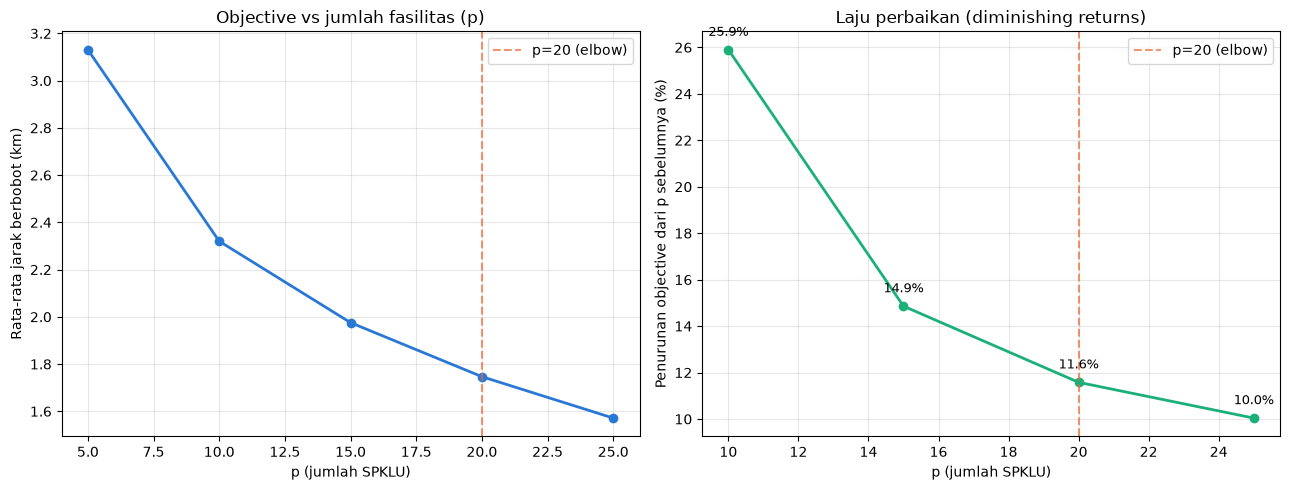

File tersimpan: d:\Magang\Week 1\spklu_bandung\outputs\pmedian_usia_25_60_v2\elbow_pmedian.png


In [56]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Objective (rata-rata jarak berbobot) vs p
ax1.plot(summary["p"], summary["rata_rata_jarak_berbobot_km"],
         marker="o", linewidth=2, color="#2a78d6")
ax1.set_xlabel("p (jumlah SPKLU)")
ax1.set_ylabel("Rata-rata jarak berbobot (km)")
ax1.set_title("Objective vs jumlah fasilitas (p)")
ax1.grid(alpha=0.3)
ax1.axvline(20, color="#eb6834", linestyle="--", alpha=0.7, label="p=20 (elbow)")
ax1.legend()

# Panel 2: Penurunan objective (%) vs p — elbow curve
ax2.plot(summary["p"], summary["penurunan_objective_persen"],
         marker="o", linewidth=2, color="#1baf7a")
ax2.set_xlabel("p (jumlah SPKLU)")
ax2.set_ylabel("Penurunan objective dari p sebelumnya (%)")
ax2.set_title("Laju perbaikan (diminishing returns)")
ax2.grid(alpha=0.3)
ax2.axvline(20, color="#eb6834", linestyle="--", alpha=0.7, label="p=20 (elbow)")
ax2.legend()

# Anotasi angka penurunan di tiap titik
for _, row in summary.iterrows():
    if not pd.isna(row["penurunan_objective_persen"]):
        ax2.annotate(f"{row['penurunan_objective_persen']:.1f}%",
                     (row["p"], row["penurunan_objective_persen"]),
                     textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "elbow_pmedian.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"File tersimpan: {OUTPUT_DIR / 'elbow_pmedian.png'}")